# Aggregating Data

DS 2023 | Communicating with Data

## Overview

In this notebook, we will look at how to use grouping variables to aggregate measurement data and to generate wide tables.

We will work with the `mpg` dataset from Seaborn.

> [!note] The data represent fuel efficiency and engine attributes for $398$ automobile models from $1970$ to $1982$. It is originally from the StatLib library and the 1983 ASA Data Exposition.

## Set Up

In [65]:
import pandas as pd
import seaborn as sns

mpg = sns.load_dataset('mpg')
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


## What kinds of variables?

Get the column names and classify them into lists.

In [4]:
mpg.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='str')

In [7]:
id_cols = ['name']
group_cols = ['origin', 'model_year'] # Does not form a key
measure_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

Re-order the dataframe.

In [8]:
mpg[id_cols + group_cols + measure_cols]

,name,origin,model_year,mpg,cylinders,displacement,horsepower,weight,acceleration
0,chevrolet chevelle malibu,usa,70,18.0,8,307.0,130.0,3504,12.0
1,buick skylark 320,usa,70,15.0,8,350.0,165.0,3693,11.5
2,plymouth satellite,usa,70,18.0,8,318.0,150.0,3436,11.0
3,amc rebel sst,usa,70,16.0,8,304.0,150.0,3433,12.0
4,ford torino,usa,70,17.0,8,302.0,140.0,3449,10.5
...,...,...,...,...,...,...,...,...,...
393,ford mustang gl,usa,82,27.0,4,140.0,86.0,2790,15.6
394,vw pickup,europe,82,44.0,4,97.0,52.0,2130,24.6
395,dodge rampage,usa,82,32.0,4,135.0,84.0,2295,11.6
396,ford ranger,usa,82,28.0,4,120.0,79.0,2625,18.6


> [!note] If we wanted to, we could extract a variable for car manufacturer like so:
> ```python
> mpg['make'] = mpg['name'].str.split().str[0]
> ``` 
> This would give us another grouping variable to work with.

## Aggregate

Grouping columns and measurement columns have a complementary relationship to each other. 

Let's look at how we can use group variables to do aggregation on the measurement variables.

To do this, we use Pandas' `groupby` function. This function takes a list of columns to group on, followed by a list of columns to which an aggregating function can be applied. If no columns are specified for the aggregation, then all columns are used.

### Grouping by one variable

Here we group our table by the variable `origin` and get the mean value of each measurment variable.

In [54]:
mpg.groupby('origin')[measure_cols].mean()

,mpg,cylinders,displacement,horsepower,weight,acceleration
origin,,,,,,
europe,27.891429,4.157143,109.142857,80.558824,2423.300000,16.787143
japan,30.450633,4.101266,102.708861,79.835443,2221.227848,16.172152
usa,20.083534,6.248996,245.901606,119.048980,3361.931727,15.033735


And here we group by `model_year` and get the means.

In [55]:
mpg.groupby('model_year')[measure_cols].mean()

,mpg,cylinders,displacement,horsepower,weight,acceleration
model_year,,,,,,
70,17.689655,6.758621,281.413793,147.827586,3372.793103,12.948276
71,21.250000,5.571429,209.750000,107.037037,2995.428571,15.142857
72,18.714286,5.821429,218.375000,120.178571,3237.714286,15.125000
73,17.100000,6.375000,256.875000,130.475000,3419.025000,14.312500
74,22.703704,5.259259,171.740741,94.230769,2877.925926,16.203704
75,20.266667,5.600000,205.533333,101.066667,3176.800000,16.050000
76,21.573529,5.647059,197.794118,101.117647,3078.735294,15.941176
77,23.375000,5.464286,191.392857,105.071429,2997.357143,15.435714
78,24.061111,5.361111,177.805556,99.694444,2861.805556,15.805556


### Grouping by two variables

We can also group by and aggregate on two variables.

In [56]:
mpg.groupby(group_cols)[measure_cols].mean()

mpg  cylinders  displacement  horsepower  \
origin model_year                                                   
europe 70          25.200000   4.000000    107.800000   86.200000   
       71          28.750000   4.000000     95.000000   74.000000   
       72          22.000000   4.000000    111.000000   79.600000   
       73          24.000000   4.000000    105.000000   81.857143   
       74          27.000000   4.000000     93.166667   74.166667   
       75          24.500000   4.000000    109.500000   89.500000   
       76          24.250000   4.250000    116.125000   87.625000   
       77          29.250000   4.000000     98.500000   81.000000   
       78          24.950000   4.833333    126.166667   99.166667   
       79          30.450000   4.250000    126.000000   72.000000   
       80          37.288889   4.111111    104.222222   66.750000   
       81          31.575000   4.500000    122.750000   76.666667   
       82          40.000000   4.000000    101.000000   63.000000   
japan  70          25.500000   4.000000    105.000000   91.500000   
       71          29.500000   4.000000     88.250000   79.250000   
       72          24.200000   3.800000     99.400000   93.800000   
       73          20.000000   4.250000    107.750000   98.500000   
       74          29.333333   4.000000     89.500000   72.500000   
       75          27.500000   4.000000    110.250000   80.250000   
       76          28.000000   4.500000    107.250000   76.500000   
       77          27.416667   4.166667    100.500000   81.166667   
       78          29.687500   4.000000    107.250000   79.250000   
       79          32.950000   4.000000     85.500000   65.000000   
       80          35.400000   4.076923    104.615385   78.846154   
       81          32.958333   4.333333    107.500000   78.333333   
       82          34.888889   4.000000    103.777778   74.000000   
usa    70          15.272727   7.636364    336.909091  166.954545   
       71          18.100000   6.200000    257.000000  119.842105   
       72          16.277778   6.888889    281.250000  138.777778   
       73          15.034483   7.241379    314.103448  146.620690   
       74          18.333333   6.266667    236.066667  112.142857   
       75          17.550000   6.400000    253.400000  108.700000   
       76          19.431818   6.363636    243.954545  110.500000   
       77          20.722222   6.222222    242.333333  118.388889   
       78          21.772727   6.000000    217.545455  107.272727   
       79          23.478261   6.260870    231.260870  109.434783   
       80          25.914286   4.285714    151.571429   88.833333   
       81          27.530769   4.923077    164.846154   84.538462   
       82          29.450000   4.300000    142.950000   86.947368   

                        weight  acceleration  
origin model_year                             
europe 70          2309.200000     16.500000  
       71          2024.000000     16.750000  
       72          2573.200000     18.700000  
       73          2335.714286     16.428571  
       74          2139.333333     15.333333  
       75          2571.166667     15.083333  
       76          2611.000000     16.050000  
       77          2138.750000     15.000000  
       78          2691.666667     16.233333  
       79          2693.750000     18.400000  
       80          2348.000000     18.366667  
       81          2725.000000     17.500000  
       82          2055.000000     19.950000  
japan  70          2251.000000     14.750000  
       71          1936.000000     16.375000  
       72          2300.400000     15.400000  
       73          2397.250000     15.625000  
       74          2053.000000     17.666667  
       75          2303.250000     16.000000  
       76          2217.500000     16.575000  
       77          2295.833333     16.316667  
       78          2221.250000     16.200000  
       79          1997.500000     17.200000  
       80          2

## Split-Apply-Combine

The pattern we are using here is called "split-apply-combine" strategy for data analysis, a term coined by [Hadley Wickham (2011)](https://www.jstatsoft.org/article/view/v040i01). Recall that he also coined the expression "tidy data".

It refers to the process of ... 
- **SPLITTING** a table in separate tables based on the domain of a group variable,
- **APPLYING** an aggregate function, like mean or sum, to each group independenty,
- and then taking the resulting rows and **COMBINING** them into a new table.

The resulting table has a row for each unique group value &mdash; i.e. the resulting table contains the **domain** of the grouping column.


![](https://ontoligentdesign.com/ds2023/images/split-apply-combine.png)
[source](https://medium.com/analytics-vidhya/split-apply-combine-strategy-for-data-mining-4fd6e2a0cc99)

## Pandas indexes

Note the structure of the tables that result from aggregating with `groupby`: The all have indexes that consist of the domains of the group variables, or every combination of them if grouping on more than one variable.

> [!tip] Indexes are an important concept in Pandas. They look like regular columns, but they behave a little differently. We'll learn more about this behavior as we apply Pandas to different datasets and problems.

## Unstacking

One of the interesting things you can do with a dataframe that has at least two index columns and one measurement column is unstack it.

Let's regenerate the aggregate table on our two group variables and save it to a new dataframe.

In [11]:
mpg_agg2 = mpg.groupby(group_cols)[measure_cols].mean()
mpg_agg2.head()

mpg  cylinders  displacement  horsepower       weight  \
origin model_year                                                            
europe 70          25.20        4.0    107.800000   86.200000  2309.200000   
       71          28.75        4.0     95.000000   74.000000  2024.000000   
       72          22.00        4.0    111.000000   79.600000  2573.200000   
       73          24.00        4.0    105.000000   81.857143  2335.714286   
       74          27.00        4.0     93.166667   74.166667  2139.333333   

                   acceleration  
origin model_year                
europe 70             16.500000  
       71             16.750000  
       72             18.700000  
       73             16.428571  
       74             15.333333

Now let's use the `unstack` method to project the domains of the two group variables onto the two axes.

We also use the transform function `T` to turn the table sideways, which gives us countries as columns.

In [14]:
mpg_agg2['mpg'].unstack().T

origin,europe,japan,usa
model_year,,,
70,25.200000,25.500000,15.272727
71,28.750000,29.500000,18.100000
72,22.000000,24.200000,16.277778
73,24.000000,20.000000,15.034483
74,27.000000,29.333333,18.333333
75,24.500000,27.500000,17.550000
76,24.250000,28.000000,19.431818
77,29.250000,27.416667,20.722222
78,24.950000,29.687500,21.772727


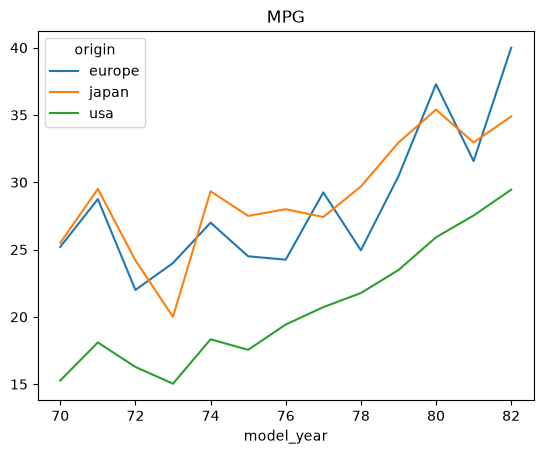

In [64]:
mpg_agg2['mpg'].unstack().T.plot(title="MPG");

In [61]:
mpg_agg2['horsepower'].unstack().T

origin,europe,japan,usa
model_year,,,
70,86.200000,91.500000,166.954545
71,74.000000,79.250000,119.842105
72,79.600000,93.800000,138.777778
73,81.857143,98.500000,146.620690
74,74.166667,72.500000,112.142857
75,89.500000,80.250000,108.700000
76,87.625000,76.500000,110.500000
77,81.000000,81.166667,118.388889
78,99.166667,79.250000,107.272727


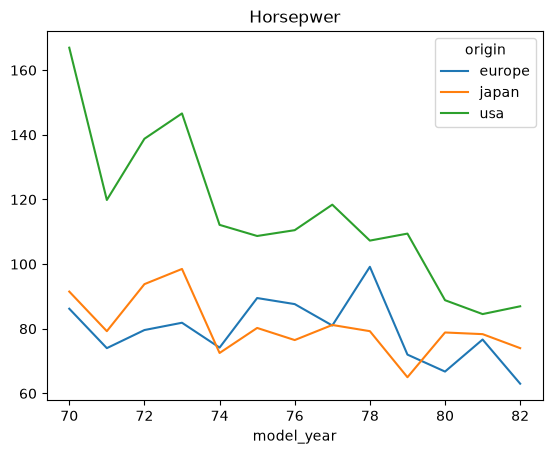

In [63]:
mpg_agg2['horsepower'].unstack().T.plot(title="Horsepwer");

## Another way to do it

We can use `pivot_table` to do an aggregated pivot.

This function is like `pivot` from the previous notebook, but requires an aggregate function.

In [12]:
mpg.pivot_table(index='model_year', columns='origin', values='mpg', aggfunc='mean')

origin,europe,japan,usa
model_year,,,
70,25.200000,25.500000,15.272727
71,28.750000,29.500000,18.100000
72,22.000000,24.200000,16.277778
73,24.000000,20.000000,15.034483
74,27.000000,29.333333,18.333333
75,24.500000,27.500000,17.550000
76,24.250000,28.000000,19.431818
77,29.250000,27.416667,20.722222
78,24.950000,29.687500,21.772727


## Why can't we just use pivot?

We noted above that the group cols do not form a unique key.

Let's demonstrate what this means by attempting to pivot the dataset on the group variables a measurement.

In [70]:
try:
    mpg.pivot(index='model_year', columns='origin', values='mpg')
except ValueError as e:
    print(e)

Index contains duplicate entries, cannot reshape


> [!caution] There is a difference between the `pivot` function and the `pivot_table` function. The former assumes that the index, columns, and values are direct transformations of observations, whereas the latter applies an aggregate function to groups of observations.
>
> The question to ask in choosing between the two is: Does the combination of group variables &mdash; being used to define the index and columns in the pivot &mdash; produce a unique set of combination or not? If they do form a key, then use `pivot`, if they do not, use `pivot_table`. In any case, if you use `pivot` incorrectly, you will get an error.

## What can you do with a wide table?

In either case, having a wide table is convenient for various reasons.

For one, it is easy to apply functions to it. 

In [18]:
mpg_year_origin = mpg_agg2['mpg'].unstack().T
mpg_year_origin

origin,europe,japan,usa
model_year,,,
70,25.200000,25.500000,15.272727
71,28.750000,29.500000,18.100000
72,22.000000,24.200000,16.277778
73,24.000000,20.000000,15.034483
74,27.000000,29.333333,18.333333
75,24.500000,27.500000,17.550000
76,24.250000,28.000000,19.431818
77,29.250000,27.416667,20.722222
78,24.950000,29.687500,21.772727


In [24]:
mpg_year_origin.mean()

origin
europe    28.401068
japan     29.025748
usa       20.682185
dtype: float64

In [26]:
mpg_year_origin.mean(axis=1)

model_year
70    21.990909
71    25.450000
72    20.825926
73    19.678161
74    24.888889
75    23.183333
76    23.893939
77    25.796296
78    25.470076
79    28.959420
80    32.867725
81    30.688034
82    34.779630
dtype: float64

In [27]:
mpg_year_origin.mean(axis=0)

origin
europe    28.401068
japan     29.025748
usa       20.682185
dtype: float64

A wide table also let's us visualize similar data.

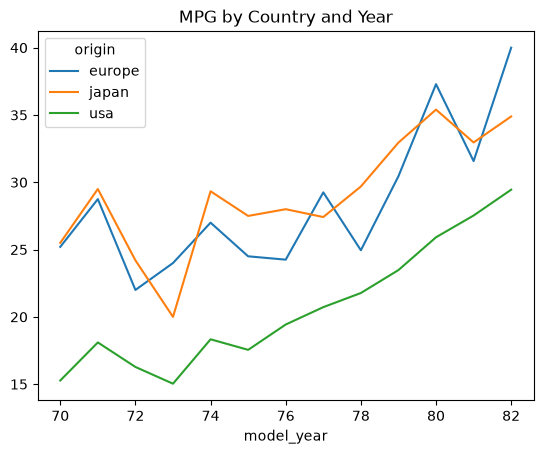

In [53]:
mpg_year_origin.plot(title="MPG by Country and Year");

## Group counting

Finally, group variables can be counted to produce aggregated tables.

In [49]:
mpg.value_counts('origin').to_frame('n')

,n
origin,
usa,249
japan,79
europe,70


In [51]:
mpg.value_counts('model_year').to_frame('n').sort_index()

,n
model_year,
70,29
71,28
72,28
73,40
74,27
75,30
76,34
77,28
78,36


Here, we count **joint** frequencies and unstack the results.

In [48]:
mpg.value_counts(group_cols).unstack().T

origin,usa,japan,europe
model_year,,,
70,22,2,5
71,20,4,4
72,18,5,5
73,29,4,7
74,15,6,6
75,20,4,6
76,22,4,8
77,18,6,4
78,22,8,6


We can clearly see that the data are imbalanced relative to `origin`.